In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# Coupling Analysis: Estimating Transfer Paths Between Channels

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/en/user_guide/tutorials/case_coupling_analysis.ipynb)


This case study promotes the legacy PEM injection tutorial into the public docs. The output is a **coupling function**: a frequency-dependent estimate of how witness-channel noise projects into the target channel.

That estimate is powerful for diagnosis, but it still models a transfer path rather than proving the physical mechanism behind it.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

from gwexpy.analysis import PercentileThreshold, SigmaThreshold, estimate_coupling
from gwexpy.noise.asd import from_pygwinc
from gwexpy.noise.wave import from_asd
from gwexpy.timeseries import TimeSeries, TimeSeriesDict

fs = 2048
duration = 32
t = np.linspace(0, duration, duration * fs, endpoint=False)

# Build background and injection states so the injected witness excess can be distinguished from the nominal detector background.
asd_target = from_pygwinc("aLIGO", fmin=3.0, fmax=fs / 2, df=1.0 / duration, quantity="strain")
asd_target.name = "L0:CAL-DARM_STRAIN"
wit_name = "L0:PEM-VOLT_GND"
wit_bkg = TimeSeries(np.random.normal(0, 1.0, len(t)), t0=0, sample_rate=fs, unit=u.V, name=wit_name)
wit_inj = TimeSeries(np.random.normal(0, 1.0, len(t)), t0=duration, sample_rate=fs, unit=u.V, name=wit_name)
wit_inj += TimeSeries(np.random.normal(0, 20, len(t)), t0=duration, sample_rate=fs, unit=u.V, name=wit_name).bandpass(20, 600)

cf_true = 2e-23 * asd_target.unit * u.Hz**0.5 / wit_bkg.unit
data_bkg = TimeSeriesDict({asd_target.name: from_asd(asd_target, duration, fs, t0=0).highpass(6).notch(8) + cf_true * wit_bkg, wit_bkg.name: wit_bkg})
data_inj = TimeSeriesDict({asd_target.name: from_asd(asd_target, duration, fs, t0=duration).highpass(6).notch(8) + cf_true * wit_inj, wit_inj.name: wit_inj})


## 1. Estimate the coupling function

The coupling function compares target excess to witness excess. If the witness injection does not produce significant target excess, the result becomes an upper limit rather than a direct estimate.

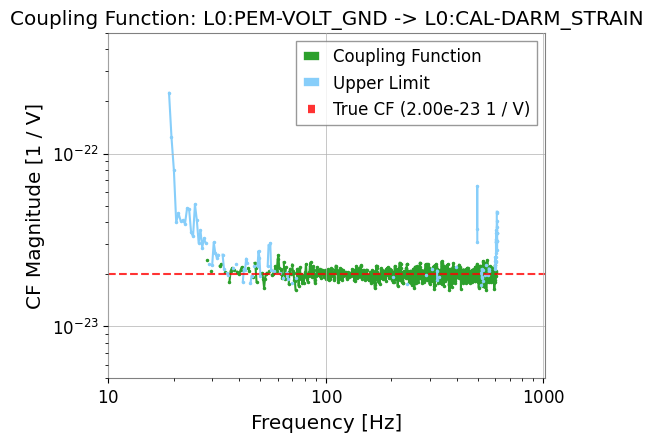

In [3]:
result = estimate_coupling(data_inj, data_bkg, fftlength=2.0, witness=wit_name)

result.plot_cf()
plt.axhline(cf_true.value, color="red", linestyle="--", alpha=0.8, label=f"True CF ({cf_true:.2e})")
plt.ylim(5e-24, 5e-22)
plt.xlim(10, 1020)
plt.legend()
plt.show()


## 2. Compare threshold strategies

Changing the threshold strategy changes how conservative the coupling estimate is. This matters when injection lines are intermittent or when the target channel barely rises above background.

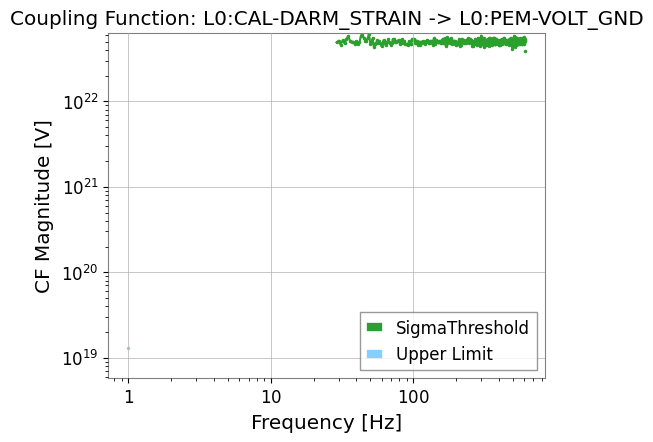

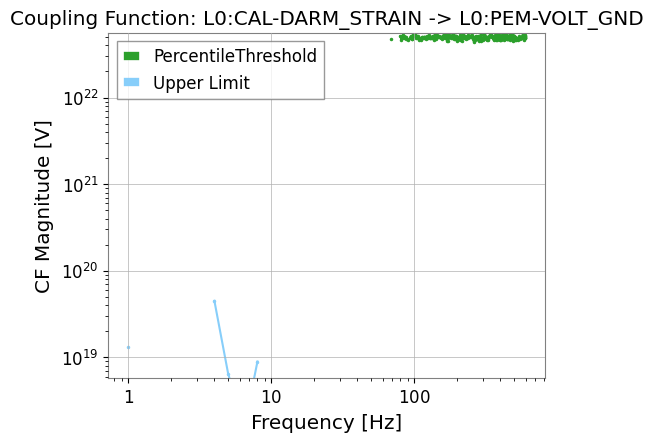

In [4]:
strategy_sigma = SigmaThreshold(sigma=5.0)
strategy_pct = PercentileThreshold(percentile=95, factor=2.0)

result_sigma = estimate_coupling(data_inj, data_bkg, fftlength=1.0, threshold_witness=strategy_sigma)
result_pct = estimate_coupling(data_inj, data_bkg, fftlength=1.0, threshold_witness=strategy_pct)

result_sigma.plot_cf(label="SigmaThreshold")
result_pct.plot_cf(label="PercentileThreshold")
plt.legend()
plt.show()
